# Step 4 — Model Implementation and Comparison

**Capstone:** AI-Powered Household Energy Consumption Prediction and Monitoring System  
**Task:** Predict next-day total household electricity consumption  
**Primary metric:** Mean Absolute Error (MAE) in kWh

This notebook compares naïve forecasting baselines with Ridge Regression, Random Forest, and XGBoost. Hyperparameters are selected with expanding-window time-series cross-validation. Candidate models are compared on the validation period, and the untouched chronological test period is used once for final evaluation.

## Success criteria carried forward from Step 1

- Final-model MAE at least 10% lower than the stronger naïve baseline.
- MAPE no greater than 15%, when actual values are safely above zero.
- High-consumption warning recall/coverage target of at least 80%.
- Warning precision target of at least 75%.
- One-day advance notice using the 120% of preceding 30-day mean threshold.

In [4]:
from pathlib import Path
from time import perf_counter
import json
import platform
import sys

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import shap
import sklearn
import xgboost

from IPython.display import display
from sklearn.base import clone
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.linear_model import Ridge
from sklearn.metrics import (
    confusion_matrix, f1_score, mean_absolute_error,
    mean_squared_error, precision_score, r2_score, recall_score,
)
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler
from xgboost import XGBRegressor

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")
sns.set_theme(style="whitegrid", context="notebook")

print(f"Python: {sys.version.split()[0]}")
print(f"Platform: {platform.platform()}")
print(f"Pandas: {pd.__version__}")
print(f"scikit-learn: {sklearn.__version__}")
print(f"XGBoost: {xgboost.__version__}")
print(f"SHAP: {shap.__version__}")

Python: 3.11.16
Platform: Windows-10-10.0.26200-SP0
Pandas: 2.3.3
scikit-learn: 1.9.1
XGBoost: 3.2.0
SHAP: 0.51.0


## 1. Paths, inputs, and reproducibility

Step 4 consumes the chronological datasets and selected feature list saved by Step 3. It does not recreate or modify the test split.

In [5]:
CURRENT_DIR = Path.cwd()
PROJECT_ROOT = CURRENT_DIR.parent if CURRENT_DIR.name.lower() == "notebooks" else CURRENT_DIR
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
MODELS_DIR = PROJECT_ROOT / "models"
TABLES_DIR = PROJECT_ROOT / "outputs" / "tables"
FIGURES_DIR = PROJECT_ROOT / "outputs" / "figures"
for directory in [MODELS_DIR, TABLES_DIR, FIGURES_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

CONFIG = {
    "random_state": RANDOM_STATE,
    "cv_splits": 5,
    "primary_metric": "MAE",
    "minimum_mae_improvement_percent": 10.0,
    "maximum_mape_percent": 15.0,
    "minimum_warning_recall": 0.80,
    "minimum_warning_precision": 0.75,
    "prediction_interval_level": 0.90,
    "bootstrap_iterations": 2000,
}

selected_features = json.loads((MODELS_DIR / "selected_features.json").read_text(encoding="utf-8"))

def load_split(name: str) -> pd.DataFrame:
    parquet_path = PROCESSED_DIR / f"{name}.parquet"
    csv_path = PROCESSED_DIR / f"{name}.csv"
    if parquet_path.exists():
        frame = pd.read_parquet(parquet_path)
    elif csv_path.exists():
        frame = pd.read_csv(csv_path, parse_dates=["target_date"], index_col="target_date")
    else:
        raise FileNotFoundError(f"Neither {parquet_path} nor {csv_path} exists.")
    frame.index = pd.to_datetime(frame.index)
    return frame.sort_index()

train = load_split("train")
validation = load_split("validation")
test = load_split("test")

required = set(selected_features) | {
    "target_daily_kwh", "high_consumption_threshold_kwh", "actual_high_consumption"
}
for name, frame in {"train": train, "validation": validation, "test": test}.items():
    missing = required - set(frame.columns)
    assert not missing, f"{name} is missing required columns: {sorted(missing)}"
    assert not frame[sorted(required)].isna().any().any(), f"{name} contains missing model values."

assert train.index.max() < validation.index.min() < test.index.min()
assert len(selected_features) == len(set(selected_features))

X_train, y_train = train[selected_features], train["target_daily_kwh"]
X_validation, y_validation = validation[selected_features], validation["target_daily_kwh"]
X_test, y_test = test[selected_features], test["target_daily_kwh"]

split_summary = pd.DataFrame({
    "split": ["Train", "Validation", "Test"],
    "rows": [len(train), len(validation), len(test)],
    "start": [train.index.min(), validation.index.min(), test.index.min()],
    "end": [train.index.max(), validation.index.max(), test.index.max()],
})
display(split_summary)
print(f"Selected features: {len(selected_features)}")

,split,rows,start,end
0,Train,802,2007-01-16,2009-05-30
1,Validation,172,2009-05-31,2010-02-23
2,Test,173,2010-02-24,2010-11-25


Selected features: 22


## 2. Evaluation functions

- **MAE:** primary metric; average absolute error in kWh.
- **RMSE:** gives greater weight to large errors.
- **MAPE:** percentage error; calculated only where actual use is nonzero.
- **R²:** proportion of variation explained relative to the mean predictor.

$$MAE=\frac{1}{n}\sum|y_i-\hat{y}_i|$$

$$RMSE=\sqrt{\frac{1}{n}\sum(y_i-\hat{y}_i)^2}$$

In [6]:
def regression_metrics(actual, predicted) -> dict:
    actual = np.asarray(actual, dtype=float)
    predicted = np.asarray(predicted, dtype=float)
    nonzero = np.abs(actual) > 1e-12
    return {
        "MAE_kWh": mean_absolute_error(actual, predicted),
        "RMSE_kWh": np.sqrt(mean_squared_error(actual, predicted)),
        "MAPE_percent": np.mean(np.abs((actual[nonzero] - predicted[nonzero]) / actual[nonzero])) * 100,
        "R2": r2_score(actual, predicted),
    }

def warning_metrics(actual_flag, predicted_flag) -> dict:
    actual_flag = np.asarray(actual_flag, dtype=int)
    predicted_flag = np.asarray(predicted_flag, dtype=int)
    tn, fp, fn, tp = confusion_matrix(actual_flag, predicted_flag, labels=[0, 1]).ravel()
    return {
        "precision": precision_score(actual_flag, predicted_flag, zero_division=0),
        "recall_coverage": recall_score(actual_flag, predicted_flag, zero_division=0),
        "f1": f1_score(actual_flag, predicted_flag, zero_division=0),
        "specificity": tn / (tn + fp) if (tn + fp) else 0.0,
        "true_negative": int(tn), "false_positive": int(fp),
        "false_negative": int(fn), "true_positive": int(tp),
    }

## 3. Naïve baselines

Two baselines establish whether machine learning adds meaningful value:

- **Persistence:** tomorrow resembles the most recently observed day (`energy_lag_1`).
- **Seasonal naïve:** tomorrow resembles the equivalent day one week earlier (`energy_lag_7`).

The stronger baseline is chosen using validation MAE and becomes the required comparison for the final test result.

In [7]:
baseline_predictions = {
    "Persistence baseline": X_validation["energy_lag_1"].to_numpy(),
    "Seasonal naive baseline": X_validation["energy_lag_7"].to_numpy(),
}
baseline_rows = []
for name, prediction in baseline_predictions.items():
    baseline_rows.append({"model": name, **regression_metrics(y_validation, prediction)})
baseline_results = pd.DataFrame(baseline_rows).sort_values("MAE_kWh").reset_index(drop=True)
stronger_baseline_name = baseline_results.iloc[0]["model"]
stronger_baseline_mae = float(baseline_results.iloc[0]["MAE_kWh"])
display(baseline_results)
print(f"Stronger validation baseline: {stronger_baseline_name}")

,model,MAE_kWh,RMSE_kWh,MAPE_percent,R2
0,Seasonal naive baseline,5.6091,7.1561,23.2322,0.3463
1,Persistence baseline,5.9696,7.9306,23.1272,0.1972


Stronger validation baseline: Seasonal naive baseline


## 4. Expanding-window cross-validation

Random K-fold validation is inappropriate for forecasting because it can train on future observations and validate on earlier observations. `TimeSeriesSplit` preserves order and expands the training window across five folds.

In [8]:
cv = TimeSeriesSplit(n_splits=CONFIG["cv_splits"])
cv_rows = []
for fold, (train_index, validation_index) in enumerate(cv.split(X_train), start=1):
    cv_rows.append({
        "fold": fold,
        "train_rows": len(train_index),
        "validation_rows": len(validation_index),
        "train_start": X_train.index[train_index[0]],
        "train_end": X_train.index[train_index[-1]],
        "validation_start": X_train.index[validation_index[0]],
        "validation_end": X_train.index[validation_index[-1]],
    })
cv_summary = pd.DataFrame(cv_rows)
display(cv_summary)
assert all(cv_summary["train_end"] < cv_summary["validation_start"])
cv_summary.to_csv(TABLES_DIR / "step4_cv_folds.csv", index=False)

,fold,train_rows,validation_rows,train_start,train_end,validation_start,validation_end
0,1,137,133,2007-01-16,2007-07-04,2007-07-05,2007-12-15
1,2,270,133,2007-01-16,2007-12-15,2007-12-16,2008-04-26
2,3,403,133,2007-01-16,2008-04-26,2008-04-27,2008-09-06
3,4,536,133,2007-01-16,2008-09-06,2008-09-07,2009-01-17
4,5,669,133,2007-01-16,2009-01-17,2009-01-18,2009-05-30


## 5. Candidate models and tuning strategy

- **Ridge Regression:** interpretable regularized linear benchmark; robust scaling is fitted inside every CV fold.
- **Random Forest:** captures nonlinearities and interactions without scaling.
- **XGBoost:** gradient-boosted trees for strong tabular forecasting performance.

Deep learning is not used because only 802 daily training rows are available after quality filtering and leakage-safe feature construction. Tree ensembles and regularized regression are more data-efficient and easier to explain for this prototype.

In [9]:
ridge_search = GridSearchCV(
    estimator=Pipeline([
        ("scaler", RobustScaler()),
        ("model", Ridge()),
    ]),
    param_grid={"model__alpha": np.logspace(-3, 3, 25)},
    scoring="neg_mean_absolute_error", cv=cv, n_jobs=-1,
    return_train_score=True,
)

rf_search = RandomizedSearchCV(
    # The outer search parallelizes fits; keep each forest single-threaded
    # to avoid nested CPU oversubscription on a local Windows machine.
    estimator=RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=1),
    param_distributions={
        "n_estimators": [250, 400, 600, 800],
        "max_depth": [None, 5, 8, 12, 16],
        "min_samples_split": [2, 5, 10, 15],
        "min_samples_leaf": [1, 2, 3, 5, 8],
        "max_features": [0.5, 0.7, 0.9, 1.0],
    },
    n_iter=24, scoring="neg_mean_absolute_error", cv=cv,
    random_state=RANDOM_STATE, n_jobs=-1, return_train_score=True,
)

xgb_search = RandomizedSearchCV(
    estimator=XGBRegressor(
        objective="reg:squarederror", eval_metric="mae",
        # The outer search parallelizes fits, so each XGBoost fit uses one
        # worker to keep resource use predictable.
        random_state=RANDOM_STATE, n_jobs=1, tree_method="hist",
    ),
    param_distributions={
        "n_estimators": [150, 250, 400, 600, 800],
        "learning_rate": [0.01, 0.03, 0.05, 0.08, 0.12],
        "max_depth": [2, 3, 4, 5, 6],
        "min_child_weight": [1, 3, 5, 8],
        "subsample": [0.65, 0.8, 1.0],
        "colsample_bytree": [0.65, 0.8, 1.0],
        "reg_alpha": [0.0, 0.01, 0.1, 1.0],
        "reg_lambda": [0.5, 1.0, 2.0, 5.0, 10.0],
    },
    n_iter=30, scoring="neg_mean_absolute_error", cv=cv,
    random_state=RANDOM_STATE, n_jobs=-1, return_train_score=True,
)

searches = {
    "Ridge Regression": ridge_search,
    "Random Forest": rf_search,
    "XGBoost": xgb_search,
}
print("Candidate searches configured. Run the next cell to tune all models.")

Candidate searches configured. Run the next cell to tune all models.


## 6. Tune candidates on training data only

The validation and test periods are not passed to hyperparameter search. Complete CV tables and the best fitted training estimator for each model are saved.

In [10]:
tuning_summary = []
for name, search in searches.items():
    print(f"Tuning {name}...")
    start = perf_counter()
    search.fit(X_train, y_train)
    elapsed = perf_counter() - start
    tuning_summary.append({
        "model": name,
        "best_cv_MAE_kWh": -search.best_score_,
        "training_seconds": elapsed,
        "best_parameters": json.dumps(search.best_params_, sort_keys=True),
    })
    pd.DataFrame(search.cv_results_).to_csv(
        TABLES_DIR / f"step4_{name.lower().replace(' ', '_')}_cv_results.csv",
        index=False,
    )
    joblib.dump(search.best_estimator_, MODELS_DIR / f"candidate_{name.lower().replace(' ', '_')}.joblib")
    print(f"  Best CV MAE: {-search.best_score_:.4f} kWh ({elapsed:.1f} seconds)")

tuning_summary = pd.DataFrame(tuning_summary).sort_values("best_cv_MAE_kWh")
display(tuning_summary)
tuning_summary.to_csv(TABLES_DIR / "step4_tuning_summary.csv", index=False)

Tuning Ridge Regression...


  Best CV MAE: 5.3472 kWh (4.8 seconds)
Tuning Random Forest...
  Best CV MAE: 5.3867 kWh (14.0 seconds)
Tuning XGBoost...
  Best CV MAE: 5.4472 kWh (7.1 seconds)


,model,best_cv_MAE_kWh,training_seconds,best_parameters
0,Ridge Regression,5.3472,4.7589,"{""model__alpha"": 56.23413251903491}"
1,Random Forest,5.3867,13.9732,"{""max_depth"": null, ""max_features"": 0.5, ""min_..."
2,XGBoost,5.4472,7.0986,"{""colsample_bytree"": 0.65, ""learning_rate"": 0...."


## 7. Validation comparison and model selection

All tuned candidates are evaluated on the same later validation period. The final model is selected by the lowest validation MAE—not by test performance. RMSE, MAPE, R², training time, and complexity provide supporting evidence.

,model,MAE_kWh,RMSE_kWh,MAPE_percent,R2,best_cv_MAE_kWh,MAE_improvement_vs_stronger_baseline_percent
0,XGBoost,4.0415,5.3451,16.7742,0.6353,5.4472,27.9478
1,Random Forest,4.1311,5.3706,17.3603,0.6318,5.3867,26.3503
2,Ridge Regression,4.2613,5.5355,18.6502,0.6089,5.3472,24.0298
3,Seasonal naive baseline,5.6091,7.1561,23.2322,0.3463,NaN,0.0000
4,Persistence baseline,5.9696,7.9306,23.1272,0.1972,NaN,-6.4260


Selected final algorithm: XGBoost
Selection basis: lowest validation MAE among trained candidate models.


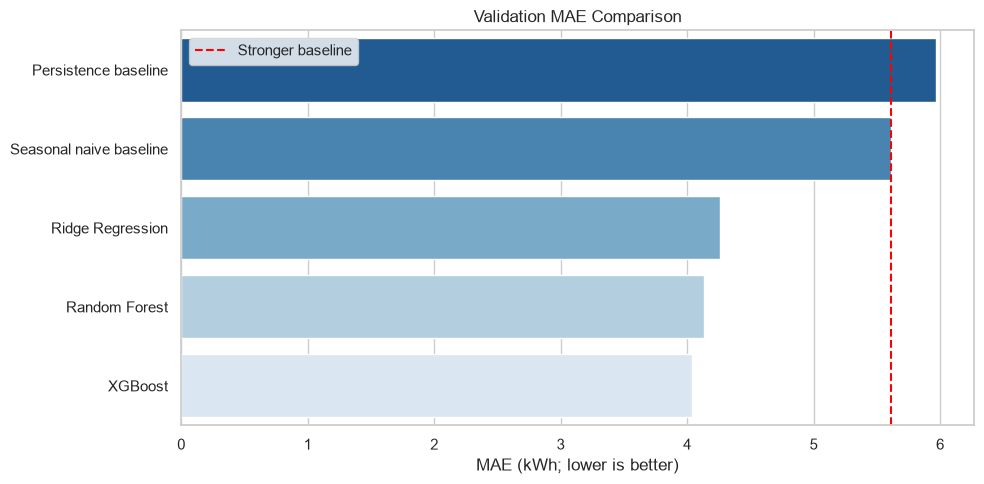

In [11]:
validation_predictions = {}
candidate_rows = []
for name, search in searches.items():
    prediction = search.best_estimator_.predict(X_validation)
    validation_predictions[name] = prediction
    candidate_rows.append({
        "model": name,
        **regression_metrics(y_validation, prediction),
        "best_cv_MAE_kWh": -search.best_score_,
    })

candidate_results = pd.DataFrame(candidate_rows).sort_values("MAE_kWh").reset_index(drop=True)
validation_comparison = pd.concat([
    baseline_results.assign(best_cv_MAE_kWh=np.nan),
    candidate_results,
], ignore_index=True).sort_values("MAE_kWh").reset_index(drop=True)
validation_comparison["MAE_improvement_vs_stronger_baseline_percent"] = (
    (stronger_baseline_mae - validation_comparison["MAE_kWh"])
    / stronger_baseline_mae * 100
)
display(validation_comparison)
validation_comparison.to_csv(TABLES_DIR / "step4_validation_model_comparison.csv", index=False)

best_model_name = candidate_results.iloc[0]["model"]
chosen_search = searches[best_model_name]
chosen_validation_prediction = validation_predictions[best_model_name]
print(f"Selected final algorithm: {best_model_name}")
print("Selection basis: lowest validation MAE among trained candidate models.")

plt.figure(figsize=(10, 5))
plot_table = validation_comparison.sort_values("MAE_kWh", ascending=False)
sns.barplot(data=plot_table, x="MAE_kWh", y="model", hue="model", legend=False, palette="Blues_r")
plt.axvline(stronger_baseline_mae, color="red", linestyle="--", label="Stronger baseline")
plt.title("Validation MAE Comparison")
plt.xlabel("MAE (kWh; lower is better)")
plt.ylabel("")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "step4_validation_mae_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. Refit the chosen model and evaluate the untouched test period

After selection, the chosen estimator is cloned and refitted on the combined train and validation periods. The test set is then evaluated once. Test results are reported honestly even if a target is not achieved.

In [12]:
X_development = pd.concat([X_train, X_validation])
y_development = pd.concat([y_train, y_validation])
final_model = clone(chosen_search.best_estimator_)
final_model.fit(X_development, y_development)
test_prediction = final_model.predict(X_test)

if stronger_baseline_name == "Persistence baseline":
    test_baseline_prediction = X_test["energy_lag_1"].to_numpy()
else:
    test_baseline_prediction = X_test["energy_lag_7"].to_numpy()

final_metrics = regression_metrics(y_test, test_prediction)
test_baseline_metrics = regression_metrics(y_test, test_baseline_prediction)
improvement = (
    (test_baseline_metrics["MAE_kWh"] - final_metrics["MAE_kWh"])
    / test_baseline_metrics["MAE_kWh"] * 100
)

test_results = pd.DataFrame([
    {"model": stronger_baseline_name, **test_baseline_metrics},
    {"model": best_model_name, **final_metrics},
])
test_results["evaluation_period"] = "Untouched test period"
display(test_results)
print(f"Final MAE improvement over stronger baseline: {improvement:.2f}%")
test_results.to_csv(TABLES_DIR / "step4_final_test_metrics.csv", index=False)

,model,MAE_kWh,RMSE_kWh,MAPE_percent,R2,evaluation_period
0,Seasonal naive baseline,5.7282,7.8624,28.6180,-0.0777,Untouched test period
1,XGBoost,3.7232,5.1040,18.7266,0.5458,Untouched test period


Final MAE improvement over stronger baseline: 35.00%


## 9. Prediction uncertainty and MAE confidence interval

A distribution-free 90% prediction band is calibrated from absolute validation residuals generated before final refitting. A bootstrap interval summarizes uncertainty around the test MAE. These intervals are descriptive and should not be interpreted as guarantees.

In [13]:
validation_absolute_residual = np.abs(y_validation.to_numpy() - chosen_validation_prediction)
interval_radius = np.quantile(validation_absolute_residual, CONFIG["prediction_interval_level"])
prediction_lower = np.maximum(0, test_prediction - interval_radius)
prediction_upper = test_prediction + interval_radius
interval_coverage = np.mean(
    (y_test.to_numpy() >= prediction_lower) & (y_test.to_numpy() <= prediction_upper)
)

absolute_test_errors = np.abs(y_test.to_numpy() - test_prediction)
rng = np.random.default_rng(RANDOM_STATE)
bootstrap_mae = np.array([
    rng.choice(absolute_test_errors, size=len(absolute_test_errors), replace=True).mean()
    for _ in range(CONFIG["bootstrap_iterations"])
])
mae_ci_lower, mae_ci_upper = np.quantile(bootstrap_mae, [0.025, 0.975])
uncertainty_summary = pd.DataFrame({
    "measure": ["Prediction interval level", "Interval radius kWh", "Observed test coverage", "Test MAE 95% CI lower", "Test MAE 95% CI upper"],
    "value": [CONFIG["prediction_interval_level"], interval_radius, interval_coverage, mae_ci_lower, mae_ci_upper],
})
display(uncertainty_summary)
uncertainty_summary.to_csv(TABLES_DIR / "step4_uncertainty_summary.csv", index=False)

,measure,value
0,Prediction interval level,0.9000
1,Interval radius kWh,8.6770
2,Observed test coverage,0.9306
3,Test MAE 95% CI lower,3.2278
4,Test MAE 95% CI upper,4.2559


## 10. High-consumption warning evaluation

A warning is generated when predicted next-day kWh exceeds 120% of the preceding 30-day mean already stored in the test data. Recall represents warning coverage; precision measures how often warnings correspond to actual high-consumption days.

,precision,recall_coverage,f1,specificity,true_negative,false_positive,false_negative,true_positive
0,0.7143,0.2174,0.3333,0.9867,148,2,18,5


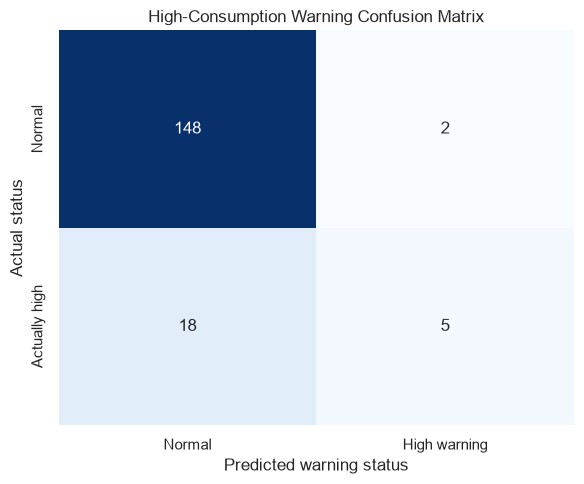

In [14]:
threshold = test["high_consumption_threshold_kwh"].to_numpy()
actual_high = test["actual_high_consumption"].astype(int).to_numpy()
predicted_high = (test_prediction > threshold).astype(int)
warning_result = warning_metrics(actual_high, predicted_high)
warning_table = pd.DataFrame([warning_result])
display(warning_table)
warning_table.to_csv(TABLES_DIR / "step4_warning_metrics.csv", index=False)

matrix = confusion_matrix(actual_high, predicted_high, labels=[0, 1])
plt.figure(figsize=(6, 5))
sns.heatmap(matrix, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["Normal", "High warning"], yticklabels=["Normal", "Actually high"])
plt.xlabel("Predicted warning status")
plt.ylabel("Actual status")
plt.title("High-Consumption Warning Confusion Matrix")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "step4_warning_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

## 11. Forecast and residual diagnostics

Time plots reveal whether errors cluster during particular periods. Residual plots assess systematic bias, changing error variance, and difficulty on high-use days.

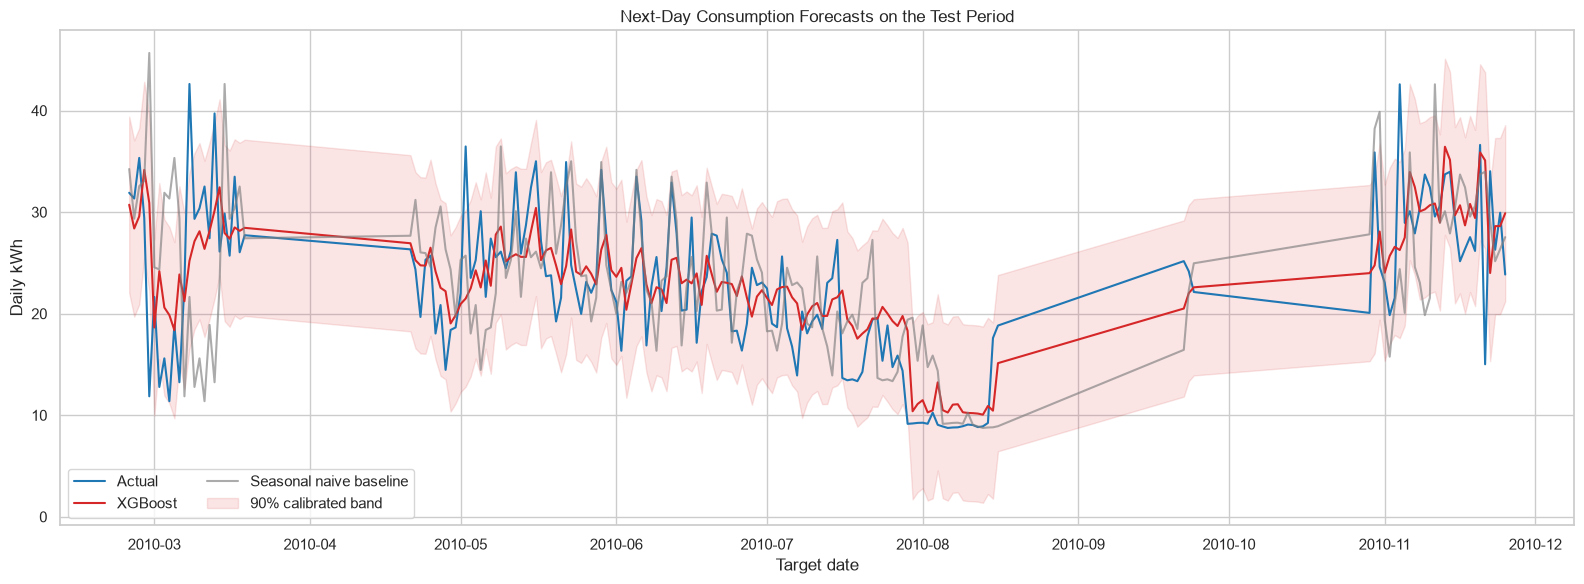

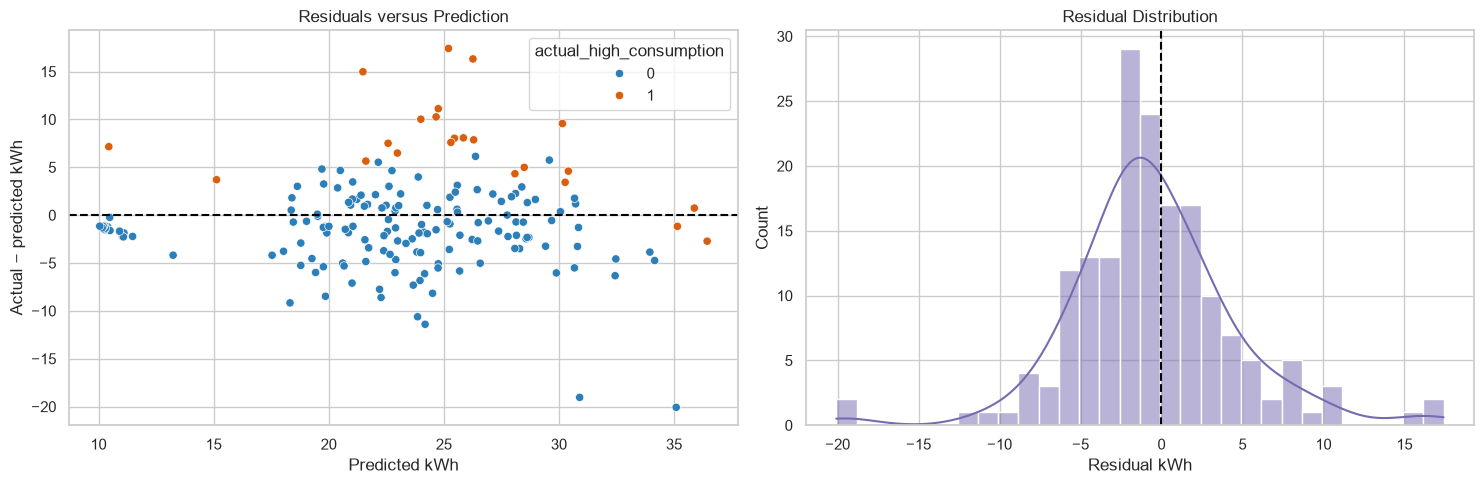

,days,MAE_kWh,median_absolute_error_kWh
actual_high_consumption,,,
Normal-consumption day,150,3.1358,2.2411
High-consumption day,23,7.5540,7.5101


In [15]:
predictions = pd.DataFrame(index=test.index)
predictions["actual_kwh"] = y_test
predictions["predicted_kwh"] = test_prediction
predictions["baseline_kwh"] = test_baseline_prediction
predictions["lower_90_kwh"] = prediction_lower
predictions["upper_90_kwh"] = prediction_upper
predictions["residual_kwh"] = predictions["actual_kwh"] - predictions["predicted_kwh"]
predictions["absolute_error_kwh"] = predictions["residual_kwh"].abs()
predictions["high_threshold_kwh"] = threshold
predictions["actual_high_consumption"] = actual_high
predictions["predicted_high_warning"] = predicted_high
predictions.to_csv(TABLES_DIR / "step4_test_predictions.csv", index_label="target_date")

fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(predictions.index, predictions["actual_kwh"], label="Actual", color="#1f77b4")
ax.plot(predictions.index, predictions["predicted_kwh"], label=best_model_name, color="#d62728")
ax.plot(predictions.index, predictions["baseline_kwh"], label=stronger_baseline_name, color="#7f7f7f", alpha=0.65)
ax.fill_between(predictions.index, predictions["lower_90_kwh"], predictions["upper_90_kwh"], color="#d62728", alpha=0.12, label="90% calibrated band")
ax.set(title="Next-Day Consumption Forecasts on the Test Period", xlabel="Target date", ylabel="Daily kWh")
ax.legend(ncol=2)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "step4_test_forecast.png", dpi=150, bbox_inches="tight")
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.scatterplot(data=predictions, x="predicted_kwh", y="residual_kwh", hue="actual_high_consumption", palette=["#2c7fb8", "#d95f0e"], ax=axes[0])
axes[0].axhline(0, color="black", linestyle="--")
axes[0].set(title="Residuals versus Prediction", xlabel="Predicted kWh", ylabel="Actual − predicted kWh")
sns.histplot(predictions["residual_kwh"], bins=30, kde=True, ax=axes[1], color="#756bb1")
axes[1].axvline(0, color="black", linestyle="--")
axes[1].set(title="Residual Distribution", xlabel="Residual kWh")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "step4_residual_diagnostics.png", dpi=150, bbox_inches="tight")
plt.show()

error_by_group = predictions.groupby("actual_high_consumption").agg(
    days=("absolute_error_kwh", "size"),
    MAE_kWh=("absolute_error_kwh", "mean"),
    median_absolute_error_kWh=("absolute_error_kwh", "median"),
).rename(index={0: "Normal-consumption day", 1: "High-consumption day"})
display(error_by_group)
error_by_group.to_csv(TABLES_DIR / "step4_error_by_consumption_group.csv")

## 12. Final-model explainability

Permutation importance measures the increase in test error when one feature is disrupted. A native coefficient or tree-importance chart provides a second view. SHAP explains the final model's prediction contributions for a reproducible test sample.

,feature,permutation_importance_mean,permutation_importance_std
4,energy_lag_1,0.8356,0.1269
3,energy_ewm_7,0.2732,0.0793
21,year_cos,0.2000,0.0925
9,energy_roll_max_14,0.1848,0.0426
20,voltage_std_v_lag_1,0.1153,0.0423
17,energy_roll_min_7,0.1128,0.0545
6,energy_lag_21,0.0847,0.0330
0,day_of_week,0.0456,0.0469
2,energy_change_7d,0.0251,0.0229
14,energy_roll_mean_7,0.0198,0.0324


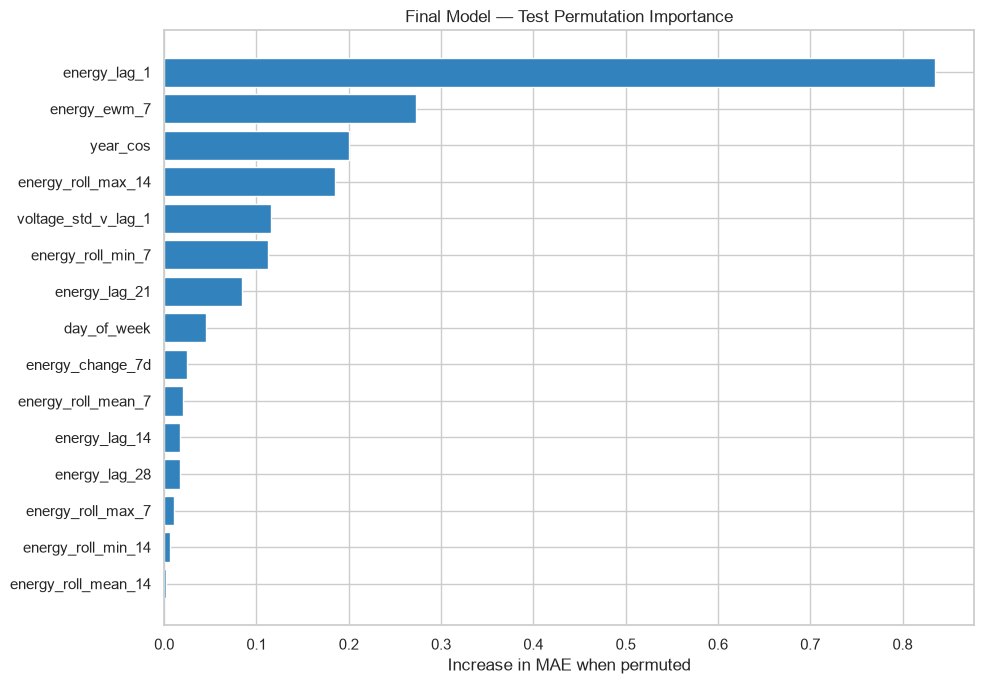

E:\AppData\Local\Temp\ipykernel_26512\2569032319.py:34: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, explain_sample, show=False, max_display=15)


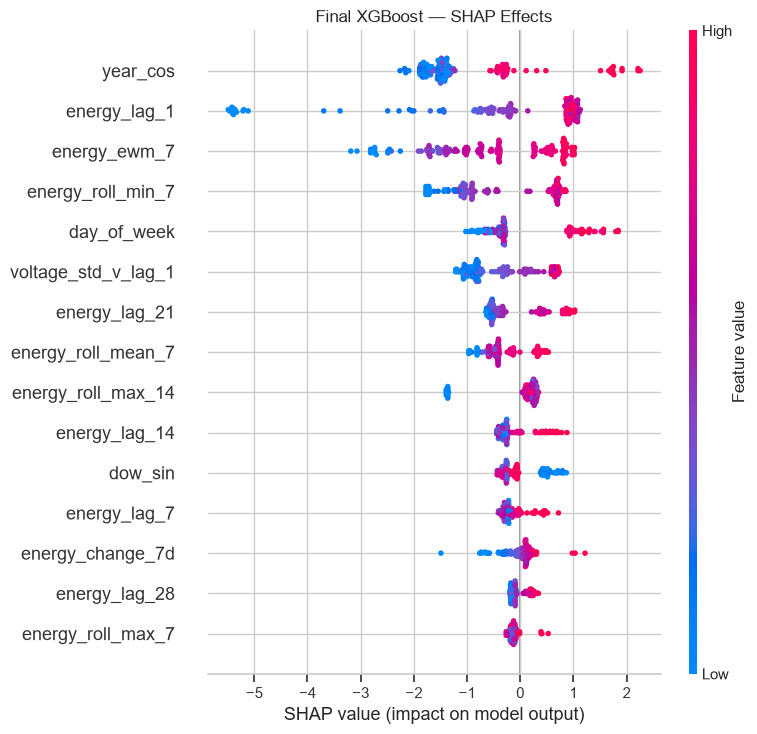

In [16]:
perm = permutation_importance(
    final_model, X_test, y_test, scoring="neg_mean_absolute_error",
    n_repeats=30, random_state=RANDOM_STATE, n_jobs=-1,
)
importance = pd.DataFrame({
    "feature": selected_features,
    "permutation_importance_mean": perm.importances_mean,
    "permutation_importance_std": perm.importances_std,
}).sort_values("permutation_importance_mean", ascending=False)
display(importance.head(20))
importance.to_csv(TABLES_DIR / "step4_final_permutation_importance.csv", index=False)

plt.figure(figsize=(10, 7))
top_importance = importance.head(15).sort_values("permutation_importance_mean")
plt.barh(top_importance["feature"], top_importance["permutation_importance_mean"], color="#3182bd")
plt.xlabel("Increase in MAE when permuted")
plt.title("Final Model — Test Permutation Importance")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "step4_final_permutation_importance.png", dpi=150, bbox_inches="tight")
plt.show()

explain_sample = X_test.sample(n=min(150, len(X_test)), random_state=RANDOM_STATE)
if best_model_name == "Ridge Regression":
    scaler = final_model.named_steps["scaler"]
    linear_model = final_model.named_steps["model"]
    background = scaler.transform(X_development.sample(n=min(200, len(X_development)), random_state=RANDOM_STATE))
    sample_values = scaler.transform(explain_sample)
    explainer = shap.LinearExplainer(linear_model, background)
    shap_values = explainer(sample_values)
    shap.summary_plot(shap_values.values, explain_sample, show=False, max_display=15)
else:
    explainer = shap.TreeExplainer(final_model)
    shap_values = explainer.shap_values(explain_sample)
    shap.summary_plot(shap_values, explain_sample, show=False, max_display=15)
plt.title(f"Final {best_model_name} — SHAP Effects")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "step4_final_shap_summary.png", dpi=150, bbox_inches="tight")
plt.show()

## 13. Success-criteria decision

Technical and warning targets are evaluated independently. A strong kWh forecast may still miss high-use warnings, so both outcomes must be reported rather than combining them into one score.

In [17]:
success_table = pd.DataFrame([
    {
        "criterion": "MAE improvement over stronger baseline",
        "target": f">= {CONFIG['minimum_mae_improvement_percent']:.0f}%",
        "observed": f"{improvement:.2f}%",
        "met": improvement >= CONFIG["minimum_mae_improvement_percent"],
    },
    {
        "criterion": "MAPE",
        "target": f"<= {CONFIG['maximum_mape_percent']:.0f}%",
        "observed": f"{final_metrics['MAPE_percent']:.2f}%",
        "met": final_metrics["MAPE_percent"] <= CONFIG["maximum_mape_percent"],
    },
    {
        "criterion": "Warning recall / coverage",
        "target": f">= {CONFIG['minimum_warning_recall']:.0%}",
        "observed": f"{warning_result['recall_coverage']:.2%}",
        "met": warning_result["recall_coverage"] >= CONFIG["minimum_warning_recall"],
    },
    {
        "criterion": "Warning precision",
        "target": f">= {CONFIG['minimum_warning_precision']:.0%}",
        "observed": f"{warning_result['precision']:.2%}",
        "met": warning_result["precision"] >= CONFIG["minimum_warning_precision"],
    },
])
display(success_table)
success_table.to_csv(TABLES_DIR / "step4_success_criteria.csv", index=False)

,criterion,target,observed,met
0,MAE improvement over stronger baseline,>= 10%,35.00%,True
1,MAPE,<= 15%,18.73%,False
2,Warning recall / coverage,>= 80%,21.74%,False
3,Warning precision,>= 75%,71.43%,False


## 14. Save final model, parameters, and provenance

The fitted final pipeline/model, every candidate estimator, search tables, predictions, configuration, feature order, library versions, split boundaries, and results are persisted. These artifacts allow the experiment to be reconstructed and audited.

In [18]:
final_model_path = MODELS_DIR / "final_energy_forecast_model.joblib"
joblib.dump(final_model, final_model_path)

best_parameters = {
    name: search.best_params_ for name, search in searches.items()
}
(MODELS_DIR / "step4_best_parameters.json").write_text(
    json.dumps(best_parameters, indent=2), encoding="utf-8"
)

run_metadata = {
    "selected_model": best_model_name,
    "selection_rule": "Lowest validation MAE among trained candidate models",
    "stronger_baseline": stronger_baseline_name,
    "selected_features": selected_features,
    "configuration": CONFIG,
    "split_boundaries": {
        "train_start": str(train.index.min()), "train_end": str(train.index.max()),
        "validation_start": str(validation.index.min()), "validation_end": str(validation.index.max()),
        "test_start": str(test.index.min()), "test_end": str(test.index.max()),
    },
    "package_versions": {
        "python": sys.version.split()[0], "pandas": pd.__version__,
        "numpy": np.__version__, "scikit_learn": sklearn.__version__,
        "xgboost": xgboost.__version__, "shap": shap.__version__,
        "joblib": joblib.__version__,
    },
    "final_test_metrics": {key: float(value) for key, value in final_metrics.items()},
    "baseline_test_metrics": {key: float(value) for key, value in test_baseline_metrics.items()},
    "mae_improvement_percent": float(improvement),
    "warning_metrics": warning_result,
    "prediction_interval": {
        "nominal_level": CONFIG["prediction_interval_level"],
        "radius_kwh": float(interval_radius),
        "observed_test_coverage": float(interval_coverage),
    },
}
(MODELS_DIR / "step4_run_metadata.json").write_text(
    json.dumps(run_metadata, indent=2), encoding="utf-8"
)

print(f"Final model saved: {final_model_path}")
print(f"Selected model: {best_model_name}")
print(f"Test MAE: {final_metrics['MAE_kWh']:.4f} kWh")
print(f"Test RMSE: {final_metrics['RMSE_kWh']:.4f} kWh")
print(f"Test MAPE: {final_metrics['MAPE_percent']:.2f}%")
print(f"Test R²: {final_metrics['R2']:.4f}")

Final model saved: e:\My_Projects\AIM\capstone\models\final_energy_forecast_model.joblib
Selected model: XGBoost
Test MAE: 3.7232 kWh
Test RMSE: 5.1040 kWh
Test MAPE: 18.73%
Test R²: 0.5458


## 15. Interpretation of the final results

### 15.1 Baseline comparison

The **seasonal naïve baseline** was stronger than the persistence baseline on the validation period. It achieved an MAE of **5.6091 kWh**, compared with **5.9696 kWh** for persistence. This result is plausible because household electricity use follows recurring weekly routines: consumption on the same day of the previous week can be more representative than consumption on the immediately preceding day. The seasonal naïve forecast was therefore retained as the official baseline for final comparison.

### 15.2 Candidate-model comparison

All three trained models substantially outperformed both naïve baselines on validation data:

| Model | Validation MAE (kWh) | RMSE (kWh) | MAPE | R² | Improvement over stronger baseline |
|---|---:|---:|---:|---:|---:|
| XGBoost | **4.0415** | **5.3451** | **16.77%** | **0.6353** | **27.95%** |
| Random Forest | 4.1311 | 5.3706 | 17.36% | 0.6318 | 26.35% |
| Ridge Regression | 4.2613 | 5.5355 | 18.65% | 0.6089 | 24.03% |
| Seasonal naïve baseline | 5.6091 | 7.1561 | 23.23% | 0.3463 | 0.00% |
| Persistence baseline | 5.9696 | 7.9306 | 23.13% | 0.1972 | −6.43% |

Ridge Regression produced the lowest mean cross-validation MAE during tuning (**5.3472 kWh**), followed by Random Forest (**5.3867 kWh**) and XGBoost (**5.4472 kWh**). However, XGBoost generalized best to the later, separate validation period. The difference between cross-validation and validation rankings also indicates that forecasting performance changes across time, reinforcing the need for chronological evaluation rather than relying on one training-period estimate.

### 15.3 Final model selection

**XGBoost was selected before the test set was evaluated** because it had the lowest validation MAE. It also produced the best validation RMSE, MAPE, and R² among the trained candidates. This made it the most defensible choice under the Step 1 rule that MAE is the primary selection metric.

The selected XGBoost configuration was then refitted on the combined training and validation periods. The chronological test period remained untouched until this final refit and evaluation.

### 15.4 Final test performance

On the untouched test period, XGBoost achieved:

- **MAE:** 3.7232 kWh
- **RMSE:** 5.1040 kWh
- **MAPE:** 18.73%
- **R²:** 0.5458

The seasonal naïve baseline produced an MAE of **5.7282 kWh**, RMSE of **7.8624 kWh**, MAPE of **28.62%**, and R² of **−0.0777**. XGBoost therefore reduced MAE by **35.00%** relative to the stronger baseline. The positive XGBoost R² indicates meaningful predictive value, whereas the baseline's negative R² indicates that it performed worse than predicting the test-period mean under that metric.

The bootstrap 95% confidence interval for test MAE was **3.2278–4.2559 kWh**. The validation-calibrated 90% prediction band used a radius of **8.6770 kWh** and covered **93.06%** of test observations. The slightly higher observed coverage suggests that the band was conservative on this test sample. It should still be presented as an uncertainty estimate rather than a guarantee.

### 15.5 Success-criteria assessment

| Criterion | Target | Observed | Result |
|---|---:|---:|---|
| MAE improvement over the stronger baseline | At least 10% | **35.00%** | Met |
| MAPE | At most 15% | **18.73%** | Not met |
| Warning recall/coverage | At least 80% | **21.74%** | Not met |
| Warning precision | At least 75% | **71.43%** | Not met |

The forecasting model met the primary baseline-improvement criterion by a wide margin. Nevertheless, it did not meet the MAPE or warning targets. The project must report these unmet targets transparently. The current system demonstrates useful next-day regression performance but is **not yet reliable enough for deployment as a high-consumption warning system**.

### 15.6 Interpretation of warning errors

There were **23 actual high-consumption days** in the test set. The warning rule correctly detected only **5**, missed **18**, and generated **2 false warnings**. This produced 21.74% recall, 71.43% precision, an F1 score of 33.33%, and specificity of 98.67%.

A **false positive** could cause a household to receive an unnecessary alert. Too many false warnings may create inconvenience, reduce trust, and lead users to ignore future messages. Only two false positives occurred, so the current rule is conservative.

A **false negative** is more consequential for the business objective because the household receives no warning before an actual high-use day. The 18 false negatives represent missed opportunities to adjust discretionary appliance use and manage the expected bill. The very high specificity combined with low recall shows that the point-forecast threshold rarely issues warnings and favors avoiding false alarms over detecting consumption spikes.

Future improvement should therefore focus on warning calibration rather than optimizing average forecast error alone. Feasible options include lowering or tuning the warning trigger on validation data, predicting an upper consumption quantile, adding a separate high-consumption classifier, or assigning a larger training penalty to underprediction on high-use days. Any revised warning rule must be selected without using the test set.

### 15.7 Error behaviour on high-consumption days

Forecast errors were substantially larger on actual high-consumption days:

- Normal-consumption days: **3.1358 kWh MAE** across 150 days
- High-consumption days: **7.5540 kWh MAE** across 23 days

The high-use-day MAE was approximately **2.41 times** the normal-day MAE. The forecast and residual plots show that the model generally follows ordinary consumption patterns but smooths some abrupt changes. This explains how the model can achieve good overall MAE while still missing most high-consumption warnings. Average-error optimization alone is therefore insufficient for the alerting objective.

### 15.8 Explainability findings

Test-set permutation importance identified **previous-day consumption (`energy_lag_1`)** as the strongest predictor by a substantial margin. Other influential variables included the seven-day exponentially weighted mean, annual cyclical position (`year_cos`), the preceding 14-day maximum, prior-day voltage variability, the preceding seven-day minimum, and the 21-day lag.

The SHAP summary supports the same general interpretation: recent consumption level, smoothed recent use, recurring annual patterns, weekly timing, and recent consumption ranges influence the forecast. These findings are consistent with household routines and seasonal demand. Several selected features had near-zero or slightly negative permutation importance on the test period, suggesting that Step 5 should examine whether they can be removed without reducing performance.

### 15.9 Limitations and final conclusion

The evaluation is based on one household in France from 2006–2010. Appliance ownership, climate, voltage conditions, household routines, and electricity-pricing conditions differ from those of Philippine and Meralco households. The results demonstrate the feasibility of the forecasting method, but they do not establish expected performance for Filipino households or prove actual bill savings.

In addition, the 173 test observations are the dates with sufficient current and historical data after quality filtering; they do not represent every uninterrupted calendar day in the nominal test date range. Results therefore apply to days for which all required leakage-safe features could be constructed.

Overall, XGBoost is the strongest tested next-day consumption model and delivers a meaningful improvement over naïve forecasting. It is suitable as the forecasting foundation for the prototype. However, the warning mechanism requires further calibration and validation—especially for high-consumption days—before it can support dependable consumer alerts.

**Next step:** Step 5 will deepen explainability, audit temporal leakage and overfitting, evaluate performance across time and consumption groups, assess ethical and generalizability risks, and test feasible warning-system mitigations without altering the untouched Step 4 test conclusion.